# Evaluación Parcial 4: Preprocesamiento de Datos para Machine Learning
**Asignatura:** ADY1100 – Preprocesamiento de Datos  
**Caso:** Banco Financiero Global – Predicción de Depósitos a Plazo  
**Dataset:** bank-additional-full.csv (41.188 registros, 21 columnas)

Este informe construye sobre el EDA realizado en la Evaluación Parcial N°2 y desarrolla el pipeline completo de preprocesamiento necesario para alimentar modelos de machine learning: tratamiento de datos faltantes, escalamiento, codificación e ingeniería de características.

---
## 0. Librerías y Carga de Datos

In [1]:
# Importación de librerías necesarias para análisis, visualización y preprocesamiento
import os
os.makedirs('graficos', exist_ok=True)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

# Carga del dataset original
df_raw = pd.read_csv('bank-additional-full.csv', sep=';')
print(f'Filas: {df_raw.shape[0]} | Columnas: {df_raw.shape[1]}')
df_raw.head(3)

Filas: 41188 | Columnas: 21


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [2]:
# ─── Pipeline de limpieza y traducción heredado de la Evaluación Parcial N°2 ───
df = df_raw.copy()

# Eliminar duplicados
df = df.drop_duplicates()

# Eliminar 'duration': data leaker documentado en el diccionario del dataset
df = df.drop(columns=['duration'])

# Traducción de valores categóricos al español
value_replacements = {
    'y':        {'yes': 'si', 'no': 'no'},
    'contact':  {'cellular': 'celular', 'telephone': 'telefono_fijo'},
    'poutcome': {'success': 'exito', 'failure': 'fracaso', 'nonexistent': 'inexistente'},
    'month':    {'jan':'ene','feb':'feb','mar':'mar','apr':'abr','may':'may',
                 'jun':'jun','jul':'jul','aug':'ago','sep':'sep','oct':'oct','nov':'nov','dec':'dic'},
    'job':      {'admin.':'administrador','blue-collar':'obrero','entrepreneur':'emprendedor',
                 'housemaid':'empleada_hogar','management':'gerencia','retired':'jubilado',
                 'self-employed':'independiente','services':'servicios','student':'estudiante',
                 'technician':'tecnico','unemployed':'desempleado','unknown':'desconocido'},
    'marital':  {'married':'casado','single':'soltero','divorced':'divorciado','unknown':'desconocido'},
    'education':{'basic.4y':'basica_4a','basic.6y':'basica_6a','basic.9y':'basica_9a',
                 'high.school':'secundaria','illiterate':'analfabeto',
                 'professional.course':'curso_profesional','university.degree':'universitario',
                 'unknown':'desconocido'},
    'default':  {'yes':'si','no':'no','unknown':'desconocido'},
    'housing':  {'yes':'si','no':'no','unknown':'desconocido'},
    'loan':     {'yes':'si','no':'no','unknown':'desconocido'}
}
for col, mapping in value_replacements.items():
    if col in df.columns:
        df[col] = df[col].replace(mapping)

# Traducción de nombres de columnas
rename_columns = {
    'y':'deposito_plazo','age':'edad','job':'trabajo','marital':'estado_civil',
    'education':'educacion','default':'mora','housing':'vivienda','loan':'prestamo',
    'contact':'contacto','month':'mes','day_of_week':'dia_semana',
    'campaign':'campana','pdays':'dias_previos','previous':'anterior',
    'poutcome':'resultado_anterior','emp.var.rate':'var_empleo',
    'cons.price.idx':'indice_precios','cons.conf.idx':'indice_confianza',
    'euribor3m':'tasa_euribor','nr.employed':'num_empleados'
}
df = df.rename(columns=rename_columns)

# Variable objetivo numérica auxiliar
df['deposito_num'] = df['deposito_plazo'].map({'si': 1, 'no': 0})

print('Dataset base listo.')
print(f'Filas: {df.shape[0]} | Columnas: {df.shape[1]}')

Dataset base listo.
Filas: 41176 | Columnas: 21


---
## 1. Tratamiento de Datos Faltantes

El dataset no presenta `NaN` reales, pero codifica ausencia de información como el valor `'desconocido'` en las variables categóricas. Antes de cualquier decisión, es necesario **cuantificar y visualizar** el problema variable por variable.

In [3]:
# Cuantificación de valores 'desconocido' por columna
cols_con_desconocido = ['trabajo', 'estado_civil', 'educacion', 'mora', 'vivienda', 'prestamo']

resumen_faltantes = []
for col in cols_con_desconocido:
    n = (df[col] == 'desconocido').sum()
    pct = n / len(df) * 100
    moda = df[df[col] != 'desconocido'][col].mode()[0]
    resumen_faltantes.append({'Variable': col, 'Desconocidos': n, 'Porcentaje (%)': round(pct, 2), 'Moda': moda})

df_faltantes = pd.DataFrame(resumen_faltantes)
print(df_faltantes.to_string(index=False))

    Variable  Desconocidos  Porcentaje (%)          Moda
     trabajo           330            0.80 administrador
estado_civil            80            0.19        casado
   educacion          1730            4.20 universitario
        mora          8596           20.88            no
    vivienda           990            2.40            si
    prestamo           990            2.40            no


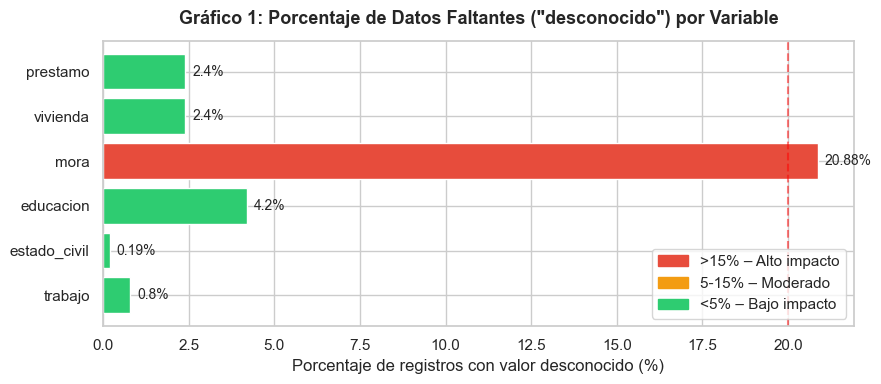

In [4]:
# ── Gráfico 1: Porcentaje de valores 'desconocido' por variable ──
# Justificación: Gráfico de barras horizontales para comparar directamente el volumen
# de datos faltantes entre variables. Permite decidir la estrategia de imputación
# basándose en el impacto real de cada columna.

fig, ax = plt.subplots(figsize=(9, 4))
colores = ['#e74c3c' if p > 15 else '#f39c12' if p > 5 else '#2ecc71'
           for p in df_faltantes['Porcentaje (%)']]
bars = ax.barh(df_faltantes['Variable'], df_faltantes['Porcentaje (%)'], color=colores)
for bar, val in zip(bars, df_faltantes['Porcentaje (%)']):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f'{val}%', va='center', fontsize=10)
ax.axvline(20, color='red', linestyle='--', alpha=0.5, label='Umbral crítico 20%')
ax.set_xlabel('Porcentaje de registros con valor desconocido (%)')
ax.set_title('Gráfico 1: Porcentaje de Datos Faltantes ("desconocido") por Variable', fontsize=13, fontweight='bold', pad=12)
ax.legend()
rojo   = mpatches.Patch(color='#e74c3c', label='>15% – Alto impacto')
naranja= mpatches.Patch(color='#f39c12', label='5-15% – Moderado')
verde  = mpatches.Patch(color='#2ecc71', label='<5% – Bajo impacto')
ax.legend(handles=[rojo, naranja, verde], loc='lower right')
plt.tight_layout()
plt.savefig('graficos/datos_faltantes_porcentaje_por_variable.png', bbox_inches='tight', dpi=150)
plt.show()

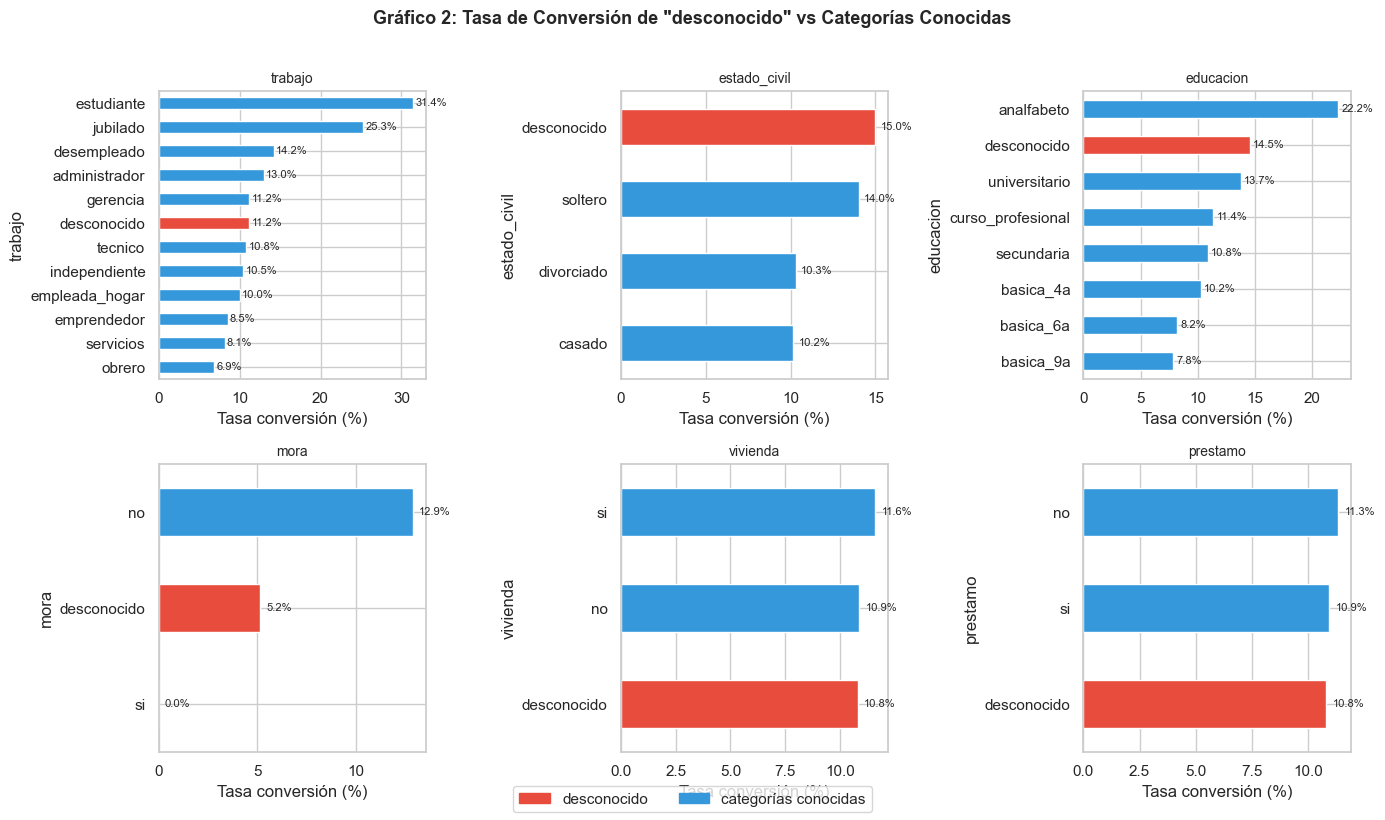

In [5]:
# ── Gráfico 2: Tasa de conversión de 'desconocido' vs valores conocidos ──
# Justificación: Antes de imputar, verificamos si 'desconocido' es informativo
# por sí mismo (si tiene una tasa de conversión diferente al resto). Si lo es,
# imputarlo puede destruir señal predictiva valiosa.

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(cols_con_desconocido):
    tasa = df.groupby(col)['deposito_num'].mean().sort_values() * 100
    colores_bar = ['#e74c3c' if idx == 'desconocido' else '#3498db' for idx in tasa.index]
    tasa.plot(kind='barh', ax=axes[i], color=colores_bar)
    axes[i].set_title(f'{col}', fontsize=10)
    axes[i].set_xlabel('Tasa conversión (%)')
    for bar, val in zip(axes[i].patches, tasa.values):
        axes[i].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                     f'{val:.1f}%', va='center', fontsize=8)

fig.suptitle('Gráfico 2: Tasa de Conversión de "desconocido" vs Categorías Conocidas', fontsize=13, fontweight='bold', y=1.01)
rojo2  = mpatches.Patch(color='#e74c3c', label='desconocido')
azul2  = mpatches.Patch(color='#3498db', label='categorías conocidas')
fig.legend(handles=[rojo2, azul2], loc='lower center', ncol=2)
plt.tight_layout()
plt.savefig('graficos/datos_faltantes_tasa_conversion_desconocido_vs_conocido.png', bbox_inches='tight', dpi=150)
plt.show()

### 1.1 Decisión de Imputación por Variable

| Variable | % Desconocido | Estrategia | Justificación |
|---|---|---|---|
| `mora` | ~20.9% | Imputación por moda (`no`) | Alto porcentaje; eliminar filas perdería demasiada información. La moda refleja el comportamiento mayoritario. |
| `educacion` | ~4.2% | Imputación por moda (`universitario`) | Porcentaje bajo. La moda es representativa. |
| `trabajo` | ~0.8% | Imputación por moda (`administrador`) | Porcentaje muy bajo, impacto mínimo. |
| `vivienda` | ~2.4% | Imputación por moda (`si`) | Porcentaje bajo. |
| `prestamo` | ~2.4% | Imputación por moda (`no`) | Porcentaje bajo. |
| `estado_civil` | ~0.2% | Imputación por moda (`casado`) | Marginal, impacto despreciable. |

In [6]:
# Aplicación de imputación por moda a cada columna con 'desconocido'
df_prep = df.copy()

for col in cols_con_desconocido:
    moda_val = df_prep[df_prep[col] != 'desconocido'][col].mode()[0]
    antes = (df_prep[col] == 'desconocido').sum()
    df_prep[col] = df_prep[col].replace('desconocido', moda_val)
    print(f'  {col}: {antes} valores imputados → "{moda_val}"')

print(f'\nDesconocidos restantes: {(df_prep[cols_con_desconocido] == "desconocido").sum().sum()}')

  trabajo: 330 valores imputados → "administrador"
  estado_civil: 80 valores imputados → "casado"
  educacion: 1730 valores imputados → "universitario"
  mora: 8596 valores imputados → "no"
  vivienda: 990 valores imputados → "si"
  prestamo: 990 valores imputados → "no"

Desconocidos restantes: 0


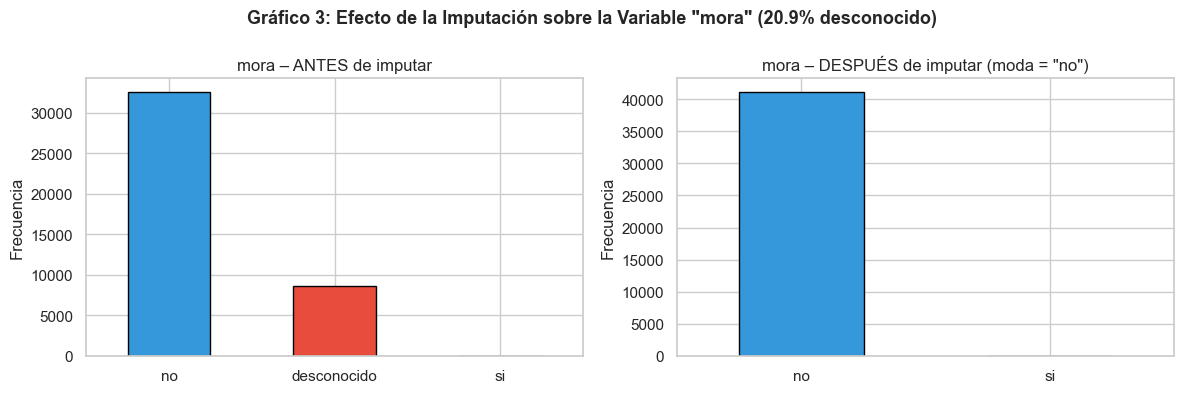

In [7]:
# ── Gráfico 3: Distribución de 'mora' antes y después de imputar ──
# Justificación: 'mora' es la variable con mayor porcentaje de faltantes (20.9%).
# Visualizar su distribución antes y después valida que la imputación no distorsionó
# artificialmente la distribución original.

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['mora'].value_counts().plot(kind='bar', ax=axes[0], color=['#3498db','#e74c3c','#f39c12'],
                                edgecolor='black')
axes[0].set_title('mora – ANTES de imputar')
axes[0].set_xlabel('')
axes[0].set_ylabel('Frecuencia')
axes[0].tick_params(axis='x', rotation=0)

df_prep['mora'].value_counts().plot(kind='bar', ax=axes[1], color=['#3498db','#e74c3c'],
                                     edgecolor='black')
axes[1].set_title('mora – DESPUÉS de imputar (moda = "no")')
axes[1].set_xlabel('')
axes[1].set_ylabel('Frecuencia')
axes[1].tick_params(axis='x', rotation=0)

fig.suptitle('Gráfico 3: Efecto de la Imputación sobre la Variable "mora" (20.9% desconocido)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('graficos/imputacion_efecto_variable_mora.png', bbox_inches='tight', dpi=150)
plt.show()

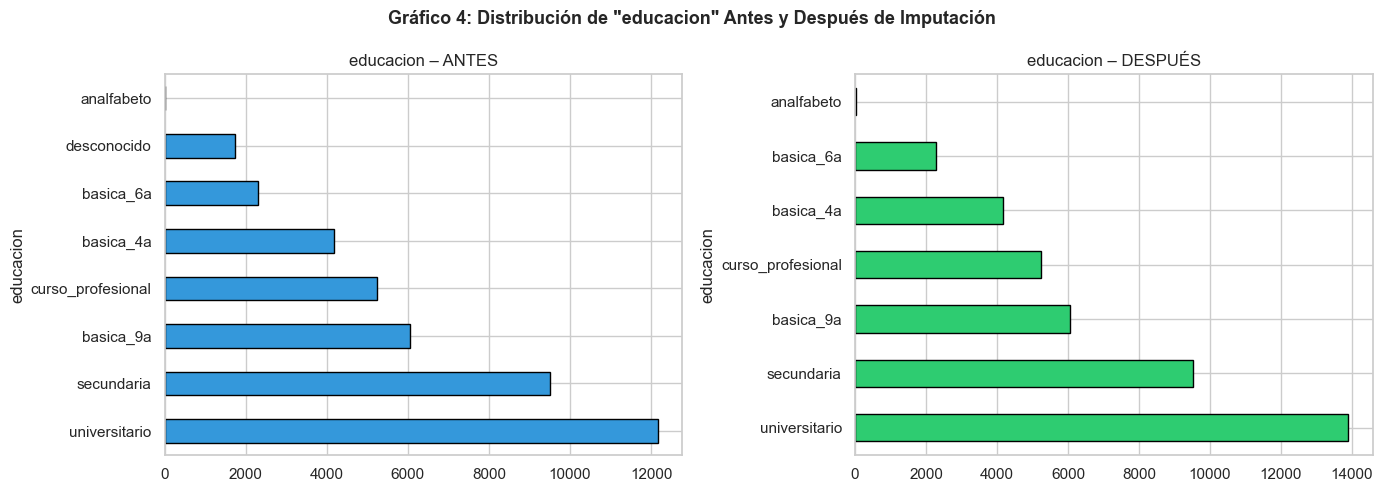

In [8]:
# ── Gráfico 4: Distribución de 'educacion' antes y después ──
# Justificación: 'educacion' es un predictor relevante según el EDA previo.
# Verificar que la imputación no colapsa las categorías minoritarias.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

order_edu = df['educacion'].value_counts().index
df['educacion'].value_counts().reindex(order_edu).plot(
    kind='barh', ax=axes[0], color='#3498db', edgecolor='black')
axes[0].set_title('educacion – ANTES')

df_prep['educacion'].value_counts().reindex(
    [x for x in order_edu if x != 'desconocido']).plot(
    kind='barh', ax=axes[1], color='#2ecc71', edgecolor='black')
axes[1].set_title('educacion – DESPUÉS')

fig.suptitle('Gráfico 4: Distribución de "educacion" Antes y Después de Imputación', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('graficos/imputacion_efecto_variable_educacion.png', bbox_inches='tight', dpi=150)
plt.show()

---
## 2. Escalamiento de Variables Numéricas

Los algoritmos de machine learning sensibles a magnitudes (Regresión Logística, KNN, SVM) se ven perjudicados cuando las variables tienen rangos muy diferentes. Por ejemplo, `num_empleados` varía entre 4.900 y 5.228, mientras que `campana` varía entre 1 y 56. Sin escalar, la primera dominaría artificialmente el modelo.

**Técnica seleccionada: StandardScaler** (z-score) → transforma cada variable para que tenga media 0 y desviación estándar 1.  
**Por qué no MinMaxScaler:** Nuestras variables numéricas tienen outliers (especialmente `campana` y `dias_previos`). MinMaxScaler es muy sensible a valores extremos porque comprime todo entre [0,1] usando el mínimo y máximo. StandardScaler es más robusto en ese contexto.

In [9]:
# Variables numéricas a escalar (excluimos la variable objetivo y la auxiliar)
num_cols = ['edad', 'campana', 'dias_previos', 'anterior',
            'var_empleo', 'indice_precios', 'indice_confianza',
            'tasa_euribor', 'num_empleados']

# Resumen estadístico ANTES del escalamiento
print('=== ANTES del escalamiento ===')
df_prep[num_cols].describe().round(2)

=== ANTES del escalamiento ===


,edad,campana,dias_previos,anterior,var_empleo,indice_precios,indice_confianza,tasa_euribor,num_empleados
count,41176.00,41176.00,41176.00,41176.00,41176.00,41176.00,41176.00,41176.00,41176.00
mean,40.02,2.57,962.46,0.17,0.08,93.58,-40.50,3.62,5167.03
std,10.42,2.77,186.94,0.49,1.57,0.58,4.63,1.73,72.25
min,17.00,1.00,0.00,0.00,-3.40,92.20,-50.80,0.63,4963.60
25%,32.00,1.00,999.00,0.00,-1.80,93.08,-42.70,1.34,5099.10
50%,38.00,2.00,999.00,0.00,1.10,93.75,-41.80,4.86,5191.00
75%,47.00,3.00,999.00,0.00,1.40,93.99,-36.40,4.96,5228.10
max,98.00,56.00,999.00,7.00,1.40,94.77,-26.90,5.04,5228.10


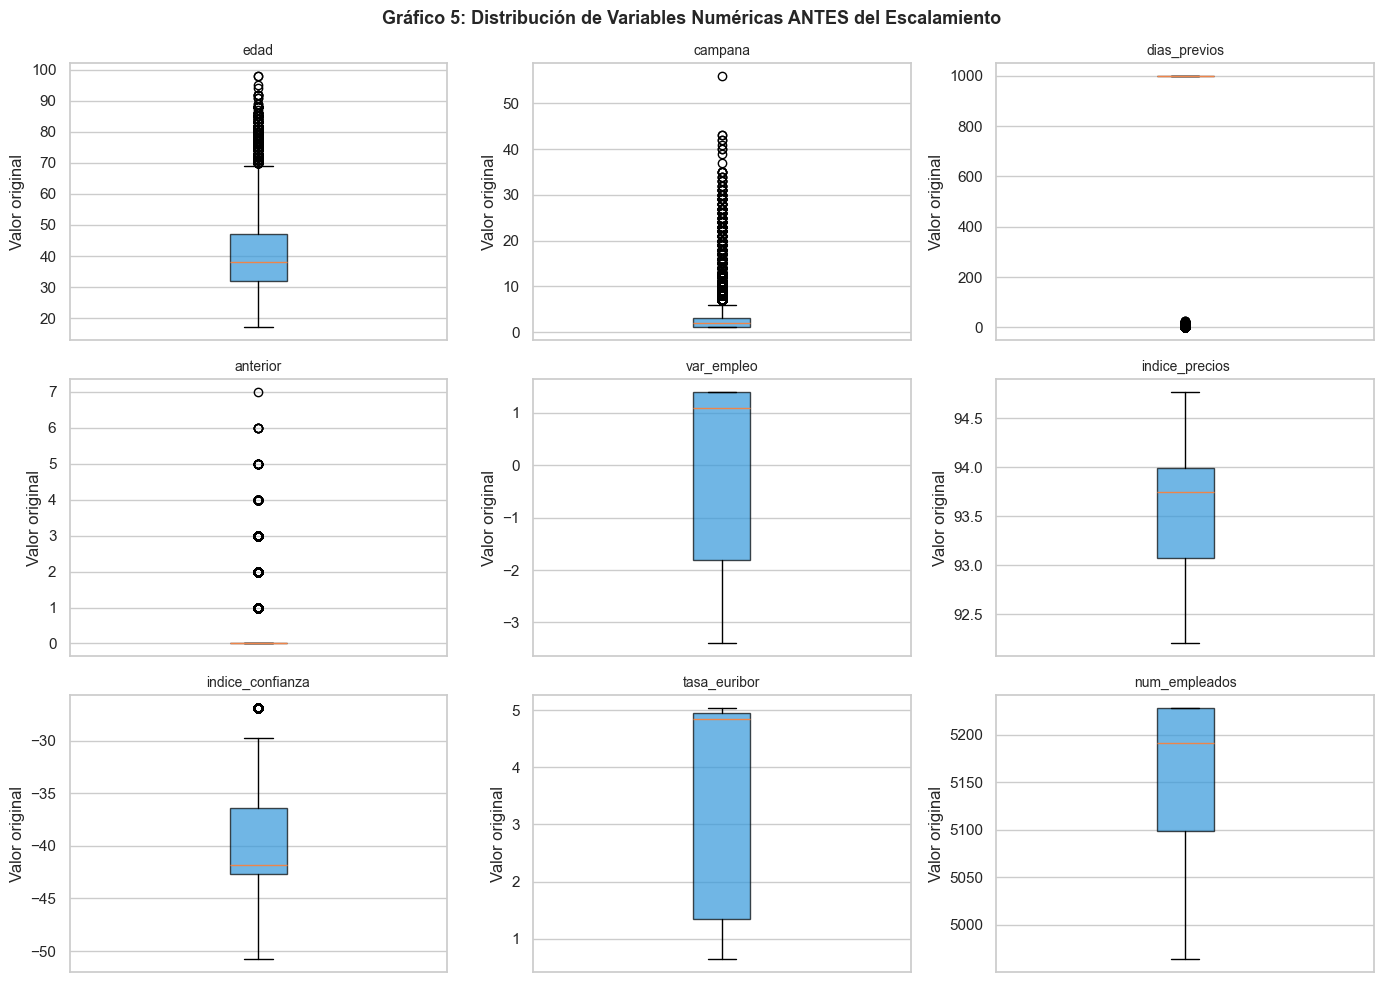

In [10]:
# ── Gráfico 5: Boxplots ANTES del escalamiento ──
# Justificación: Los boxplots muestran simultáneamente la mediana, dispersión y outliers
# de cada variable. Este gráfico evidencia por qué el escalamiento es necesario:
# los rangos completamente distintos entre variables harían que un modelo sin escalar
# asigne peso incorrecto a variables de mayor magnitud numérica.

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].boxplot(df_prep[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='#3498db', alpha=0.7))
    axes[i].set_title(col, fontsize=10)
    axes[i].set_ylabel('Valor original')
    axes[i].set_xticks([])

fig.suptitle('Gráfico 5: Distribución de Variables Numéricas ANTES del Escalamiento', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('graficos/escalamiento_distribucion_numericas_antes.png', bbox_inches='tight', dpi=150)
plt.show()

In [11]:
# Aplicación de StandardScaler
scaler = StandardScaler()
df_scaled = df_prep.copy()
df_scaled[num_cols] = scaler.fit_transform(df_prep[num_cols])

print('=== DESPUÉS del escalamiento ===')
df_scaled[num_cols].describe().round(3)

=== DESPUÉS del escalamiento ===


,edad,campana,dias_previos,anterior,var_empleo,indice_precios,indice_confianza,tasa_euribor,num_empleados
count,41176.000,41176.000,41176.000,41176.000,41176.000,41176.000,41176.000,41176.000,41176.000
mean,0.000,0.000,-0.000,0.000,-0.000,0.000,-0.000,-0.000,0.000
std,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
min,-2.209,-0.566,-5.149,-0.350,-2.217,-2.375,-2.225,-1.722,-2.816
25%,-0.770,-0.566,0.195,-0.350,-1.198,-0.865,-0.475,-1.313,-0.940
50%,-0.194,-0.205,0.195,-0.350,0.648,0.299,-0.280,0.712,0.332
75%,0.669,0.156,0.195,-0.350,0.839,0.723,0.887,0.772,0.845
max,5.564,19.288,0.195,13.793,0.839,2.058,2.939,0.821,0.845


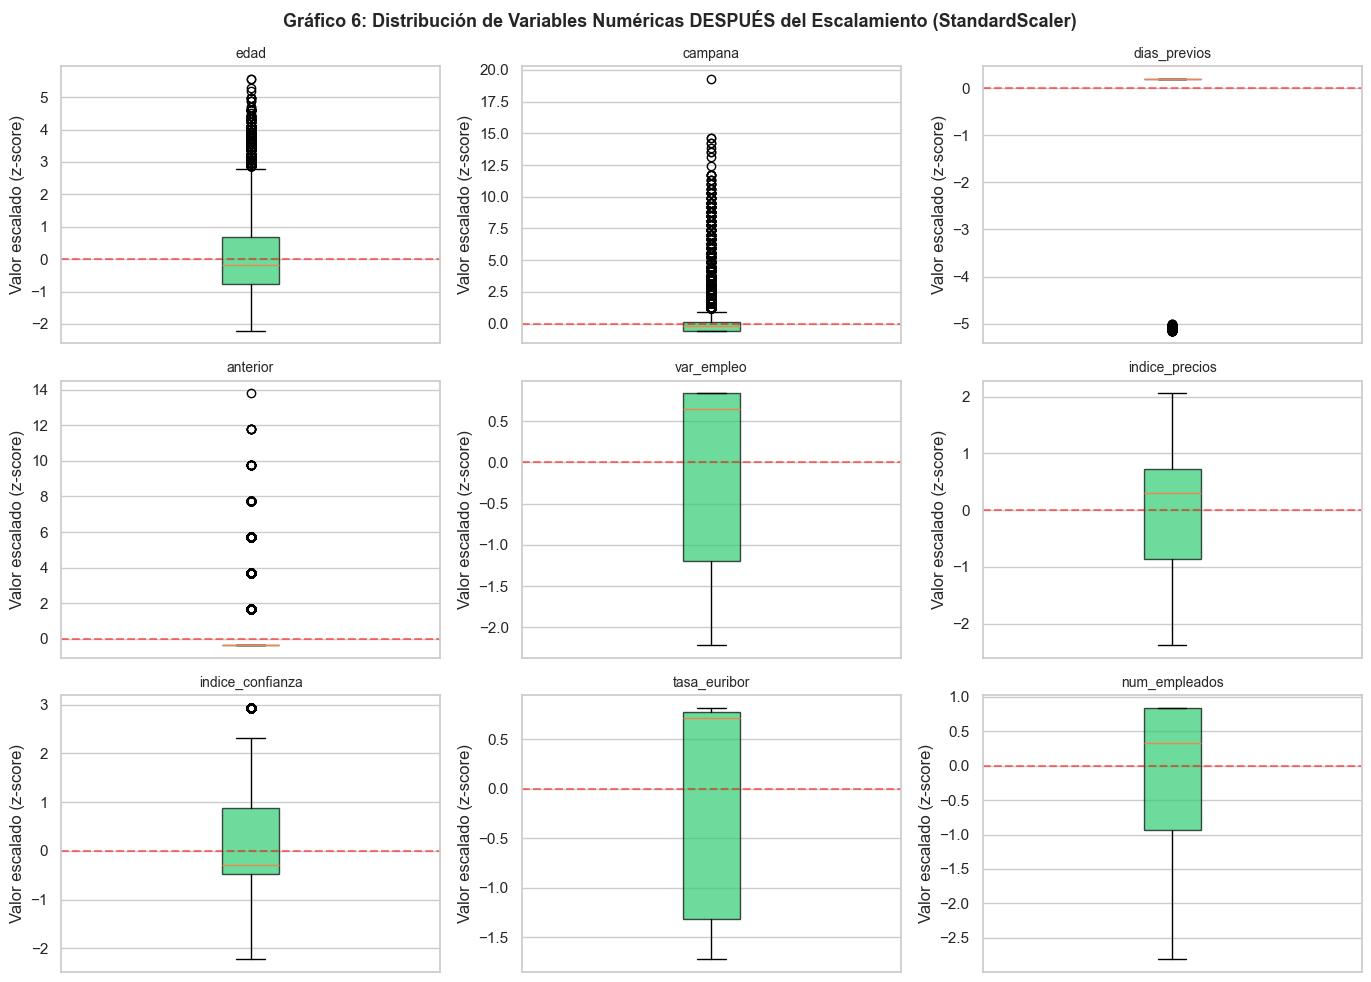

In [12]:
# ── Gráfico 6: Boxplots DESPUÉS del escalamiento ──
# Justificación: Confirma que tras aplicar StandardScaler todas las variables
# quedan centradas en 0 y con escala comparable. Ahora ninguna variable domina
# por magnitud y los algoritmos pueden comparar coeficientes directamente.

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].boxplot(df_scaled[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='#2ecc71', alpha=0.7))
    axes[i].set_title(col, fontsize=10)
    axes[i].set_ylabel('Valor escalado (z-score)')
    axes[i].set_xticks([])
    axes[i].axhline(0, color='red', linestyle='--', alpha=0.5)

fig.suptitle('Gráfico 6: Distribución de Variables Numéricas DESPUÉS del Escalamiento (StandardScaler)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('graficos/escalamiento_distribucion_numericas_despues.png', bbox_inches='tight', dpi=150)
plt.show()

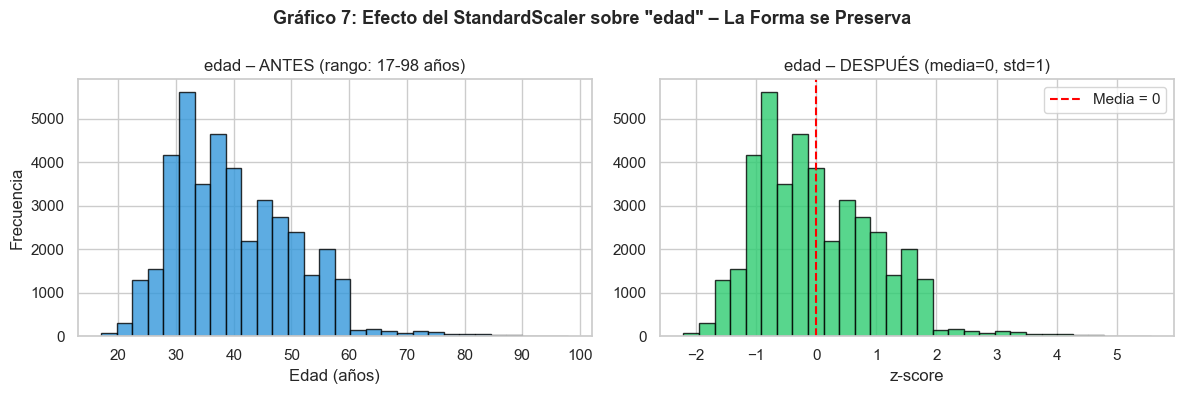

In [13]:
# ── Gráfico 7: Comparación directa Antes vs Después – variable 'edad' ──
# Justificación: Histograma superpuesto que demuestra que el escalamiento preserva
# la forma de la distribución (normalidad, sesgo) pero transforma el rango numérico.
# La variable 'edad' se eligió por ser la más intuitiva y fácil de interpretar.

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_prep['edad'], bins=30, color='#3498db', edgecolor='black', alpha=0.8)
axes[0].set_title('edad – ANTES (rango: 17-98 años)')
axes[0].set_xlabel('Edad (años)')
axes[0].set_ylabel('Frecuencia')

axes[1].hist(df_scaled['edad'], bins=30, color='#2ecc71', edgecolor='black', alpha=0.8)
axes[1].set_title('edad – DESPUÉS (media=0, std=1)')
axes[1].set_xlabel('z-score')
axes[1].axvline(0, color='red', linestyle='--', label='Media = 0')
axes[1].legend()

fig.suptitle('Gráfico 7: Efecto del StandardScaler sobre "edad" – La Forma se Preserva', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('graficos/escalamiento_efecto_standardscaler_edad.png', bbox_inches='tight', dpi=150)
plt.show()

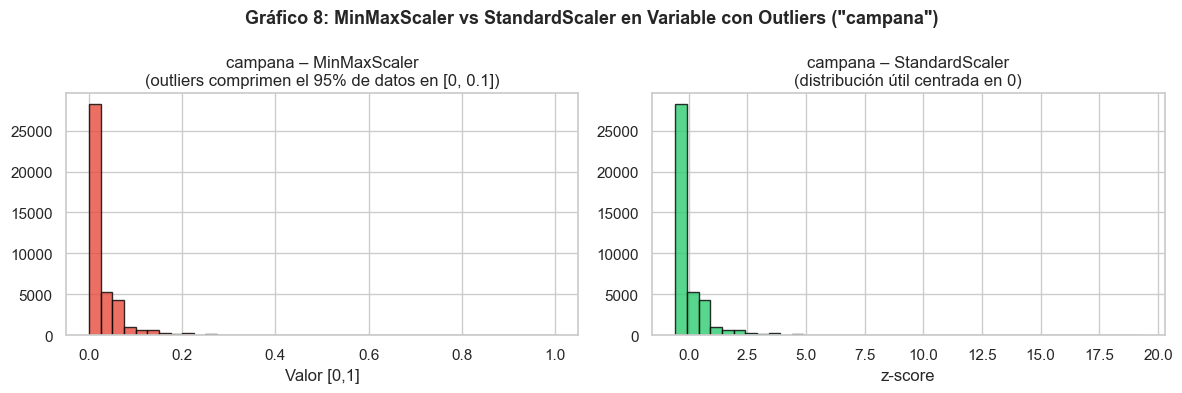

In [14]:
# ── Gráfico 8: StandardScaler vs MinMaxScaler en variable con outliers ('campana') ──
# Justificación: Evidencia por qué StandardScaler es superior para este dataset.
# MinMaxScaler comprime la mayoría de datos en un rango ínfimo cuando hay outliers
# extremos (campana tiene valores de hasta 56 llamadas), perdiendo discriminación.

minmax = MinMaxScaler()
campana_minmax = minmax.fit_transform(df_prep[['campana']]).flatten()
campana_std    = scaler.fit_transform(df_prep[['campana']]).flatten()
# Reajustar scaler con todas las columnas
scaler2 = StandardScaler()
df_scaled[num_cols] = scaler2.fit_transform(df_prep[num_cols])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(campana_minmax, bins=40, color='#e74c3c', edgecolor='black', alpha=0.8)
axes[0].set_title('campana – MinMaxScaler\n(outliers comprimen el 95% de datos en [0, 0.1])')
axes[0].set_xlabel('Valor [0,1]')

axes[1].hist(campana_std, bins=40, color='#2ecc71', edgecolor='black', alpha=0.8)
axes[1].set_title('campana – StandardScaler\n(distribución útil centrada en 0)')
axes[1].set_xlabel('z-score')

fig.suptitle('Gráfico 8: MinMaxScaler vs StandardScaler en Variable con Outliers ("campana")', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('graficos/escalamiento_minmax_vs_standard_campana.png', bbox_inches='tight', dpi=150)
plt.show()

---
## 3. Codificación de Variables Categóricas

Los algoritmos de ML no aceptan texto. Cada variable categórica requiere una técnica de codificación específica según su naturaleza:

| Variable | Técnica | Justificación |
|---|---|---|
| `deposito_plazo` | Label Encoding (0/1) | Variable objetivo binaria |
| `contacto` | Label Encoding (0/1) | Solo 2 categorías, sin orden |
| `mora`, `vivienda`, `prestamo` | Label Encoding (0/1) | Binarias (si/no) |
| `dia_semana` | Label Encoding (0-4) | 5 días, orden implícito útil |
| `trabajo`, `estado_civil`, `poutcome` | One-Hot Encoding | Nominales sin orden, múltiples categorías |
| `mes` | One-Hot Encoding | Nominal cíclico; OHE evita falsos ordinales |
| `educacion` | Ordinal Encoding | Tiene jerarquía real: analfabeto → universitario |

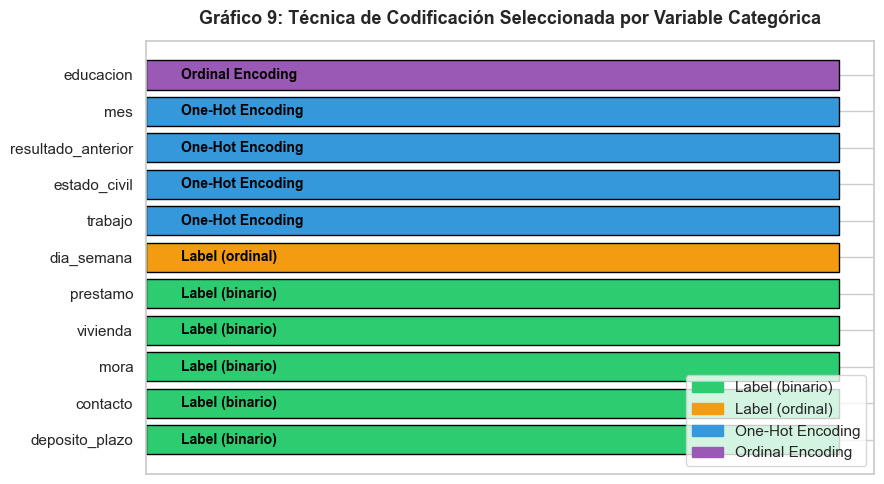

In [15]:
# ── Gráfico 9: Mapa de técnica de codificación por variable ──
# Justificación: Visualización de la decisión de codificación para cada variable
# categórica. Permite comunicar la lógica de selección de técnica de forma clara.

tecnicas = {
    'deposito_plazo':     'Label (binario)',
    'contacto':           'Label (binario)',
    'mora':               'Label (binario)',
    'vivienda':           'Label (binario)',
    'prestamo':           'Label (binario)',
    'dia_semana':         'Label (ordinal)',
    'trabajo':            'One-Hot Encoding',
    'estado_civil':       'One-Hot Encoding',
    'resultado_anterior': 'One-Hot Encoding',
    'mes':                'One-Hot Encoding',
    'educacion':          'Ordinal Encoding',
}
color_map = {
    'Label (binario)':  '#2ecc71',
    'Label (ordinal)':  '#f39c12',
    'One-Hot Encoding': '#3498db',
    'Ordinal Encoding': '#9b59b6',
}

fig, ax = plt.subplots(figsize=(9, 5))
vars_list = list(tecnicas.keys())
tecs_list = list(tecnicas.values())
colors_list = [color_map[t] for t in tecs_list]
bars = ax.barh(vars_list, [1]*len(vars_list), color=colors_list, edgecolor='black')
for bar, tec in zip(bars, tecs_list):
    ax.text(0.05, bar.get_y() + bar.get_height()/2, tec,
            va='center', fontsize=10, color='black', fontweight='bold')
ax.set_xticks([])
ax.set_xlabel('')
ax.set_title('Gráfico 9: Técnica de Codificación Seleccionada por Variable Categórica', fontsize=13, fontweight='bold', pad=12)
patches = [mpatches.Patch(color=v, label=k) for k, v in color_map.items()]
ax.legend(handles=patches, loc='lower right')
plt.tight_layout()
plt.savefig('graficos/codificacion_tecnica_por_variable.png', bbox_inches='tight', dpi=150)
plt.show()

In [16]:
# ── 3.1 Label Encoding – Variables binarias y ordinales ──
df_encoded = df_scaled.copy()

# Variable objetivo
df_encoded['deposito_plazo'] = df_encoded['deposito_plazo'].map({'si': 1, 'no': 0})

# Binarias simples
binarias = {'mora': {'si':1,'no':0}, 'vivienda': {'si':1,'no':0}, 'prestamo': {'si':1,'no':0}}
for col, mapping in binarias.items():
    df_encoded[col] = df_encoded[col].map(mapping)

# Contacto (2 categorías nominales)
df_encoded['contacto'] = df_encoded['contacto'].map({'celular': 1, 'telefono_fijo': 0})

# Día de la semana (ordinal implícito: lunes=0 … viernes=4)
dia_order = {'mon': 0, 'tue': 1, 'wed': 2, 'thu': 3, 'fri': 4}
df_encoded['dia_semana'] = df_encoded['dia_semana'].map(dia_order)

print('Label Encoding aplicado:')
print(df_encoded[['deposito_plazo','mora','vivienda','prestamo','contacto','dia_semana']].head(5))

Label Encoding aplicado:
   deposito_plazo  mora  vivienda  prestamo  contacto  dia_semana
0               0     0         0         0         0           0
1               0     0         0         0         0           0
2               0     0         1         0         0           0
3               0     0         0         0         0           0
4               0     0         0         1         0           0


In [17]:
# ── 3.2 Ordinal Encoding – 'educacion' ──
# Justificación: educacion tiene jerarquía real (mayor nivel = más educación).
# Asignar un valor numérico que respete ese orden es más informativo que OHE,
# que destruiría la relación ordinal entre categorías.

orden_educacion = {
    'analfabeto': 0,
    'basica_4a': 1,
    'basica_6a': 2,
    'basica_9a': 3,
    'secundaria': 4,
    'curso_profesional': 5,
    'universitario': 6
}
df_encoded['educacion'] = df_encoded['educacion'].map(orden_educacion)
print('Ordinal Encoding educacion:')
print(df_encoded[['educacion']].value_counts().sort_index())

Ordinal Encoding educacion:
educacion
0               18
1             4176
2             2291
3             6045
4             9512
5             5240
6            13894
Name: count, dtype: int64


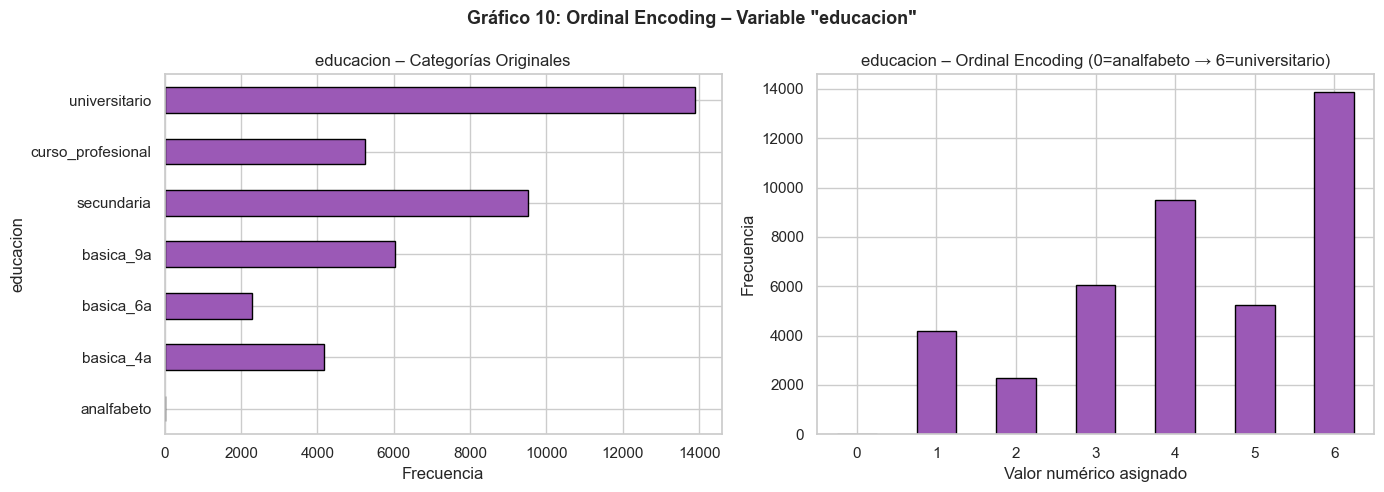

In [18]:
# ── Gráfico 10: Visualización del Ordinal Encoding de 'educacion' ──
# Justificación: Muestra visualmente que el encoding preserva la jerarquía
# educativa y que la distribución numérica resultante es coherente con la realidad.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original
edu_original = df_prep['educacion'].value_counts()
edu_original.reindex([k for k in orden_educacion.keys() if k in edu_original.index]).plot(
    kind='barh', ax=axes[0], color='#9b59b6', edgecolor='black')
axes[0].set_title('educacion – Categorías Originales')
axes[0].set_xlabel('Frecuencia')

# Encoded
df_encoded['educacion'].value_counts().sort_index().plot(
    kind='bar', ax=axes[1], color='#9b59b6', edgecolor='black')
axes[1].set_title('educacion – Ordinal Encoding (0=analfabeto → 6=universitario)')
axes[1].set_xlabel('Valor numérico asignado')
axes[1].set_ylabel('Frecuencia')
axes[1].tick_params(axis='x', rotation=0)

fig.suptitle('Gráfico 10: Ordinal Encoding – Variable "educacion"', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('graficos/codificacion_ordinal_educacion.png', bbox_inches='tight', dpi=150)
plt.show()

In [19]:
# ── 3.3 One-Hot Encoding – Variables nominales sin orden ──
# Justificación: Para variables como 'trabajo' o 'mes', no existe relación ordinal.
# OHE crea una columna binaria por categoría, evitando que el modelo interprete
# falsas relaciones de magnitud entre categorías.

cols_ohe = ['trabajo', 'estado_civil', 'resultado_anterior', 'mes']
df_encoded = pd.get_dummies(df_encoded, columns=cols_ohe, drop_first=True)

print(f'Columnas antes de OHE: {df_scaled.shape[1]}')
print(f'Columnas después de OHE: {df_encoded.shape[1]}')
print(f'\nNuevas columnas generadas: {df_encoded.shape[1] - df_scaled.shape[1]}')
print('\nEjemplo columnas OHE generadas:')
ohe_cols = [c for c in df_encoded.columns if any(c.startswith(base+'_') for base in cols_ohe)]
print(ohe_cols)

Columnas antes de OHE: 21
Columnas después de OHE: 40

Nuevas columnas generadas: 19

Ejemplo columnas OHE generadas:
['trabajo_desempleado', 'trabajo_empleada_hogar', 'trabajo_emprendedor', 'trabajo_estudiante', 'trabajo_gerencia', 'trabajo_independiente', 'trabajo_jubilado', 'trabajo_obrero', 'trabajo_servicios', 'trabajo_tecnico', 'estado_civil_divorciado', 'estado_civil_soltero', 'resultado_anterior_fracaso', 'resultado_anterior_inexistente', 'mes_ago', 'mes_dic', 'mes_jul', 'mes_jun', 'mes_mar', 'mes_may', 'mes_nov', 'mes_oct', 'mes_sep']


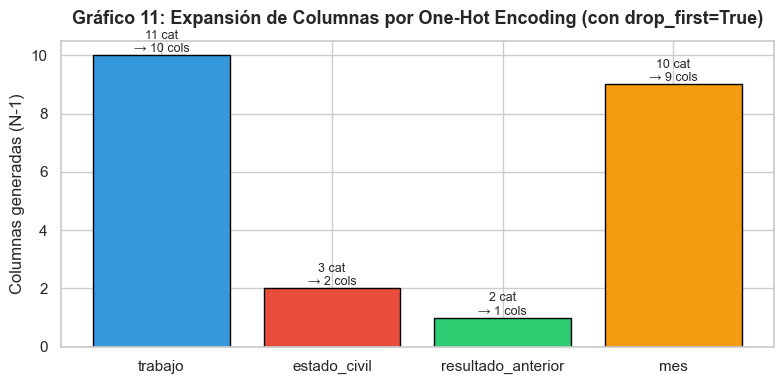

In [20]:
# ── Gráfico 11: Expansión de columnas por OHE ──
# Justificación: Visualiza el impacto de OHE en la dimensionalidad del dataset.
# Cada variable nominal se expande en N-1 columnas binarias. Permite evaluar
# el trade-off entre representación correcta y aumento de dimensionalidad.

expansion = {'trabajo': 11, 'estado_civil': 3, 'resultado_anterior': 2, 'mes': 10}
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(expansion.keys(), [v-1 for v in expansion.values()],
              color=['#3498db','#e74c3c','#2ecc71','#f39c12'], edgecolor='black')
for bar, (var, n) in zip(bars, expansion.items()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{n} cat\n→ {n-1} cols', ha='center', fontsize=9)
ax.set_ylabel('Columnas generadas (N-1)')
ax.set_title('Gráfico 11: Expansión de Columnas por One-Hot Encoding (con drop_first=True)', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('graficos/codificacion_ohe_expansion_columnas.png', bbox_inches='tight', dpi=150)
plt.show()

---
## 4. Ingeniería de Características (Feature Engineering)

El EDA de la Evaluación N°2 identificó patrones claros que podemos convertir en variables directamente predictivas. La ingeniería de características transforma conocimiento del negocio en señales que el modelo puede aprovechar.

In [21]:
# Trabajamos sobre df_prep (post-imputación, antes de escalar/encodear)
# para crear las features en espacio interpretable, luego se integran al pipeline
df_feat = df_prep.copy()

# ── Feature 1: fue_contactado_antes ──
# pdays = 999 significa que nunca fue contactado. El EDA mostró que clientes
# con contacto previo tienen tasas de conversión radicalmente distintas.
df_feat['fue_contactado_antes'] = (df_feat['dias_previos'] != 999).astype(int)
print('Feature 1 - fue_contactado_antes:')
print(df_feat['fue_contactado_antes'].value_counts())

Feature 1 - fue_contactado_antes:
fue_contactado_antes
0    39661
1     1515
Name: count, dtype: int64


In [22]:
# ── Feature 2: grupo_etario ──
# El EDA mostró que jubilados (>60) y estudiantes (jóvenes) tienen tasas de
# conversión superiores. Agrupar edad captura esta no-linealidad mejor que
# la edad cruda como número continuo.
bins   = [0, 25, 35, 45, 60, 100]
labels = ['joven', 'adulto_joven', 'adulto', 'maduro', 'senior']
df_feat['grupo_etario'] = pd.cut(df_feat['edad'], bins=bins, labels=labels)
print('\nFeature 2 - grupo_etario:')
print(df_feat['grupo_etario'].value_counts())


Feature 2 - grupo_etario:
grupo_etario
adulto_joven    14844
adulto          12839
maduro          10919
joven            1665
senior            909
Name: count, dtype: int64


In [23]:
# ── Feature 3: ratio_contactos ──
# Mide la «intensidad relativa» de la campaña actual vs el historial previo.
# Un ratio alto indica que el banco está insistiendo mucho más que antes:
# el EDA mostró que demasiadas llamadas actuales reducen la conversión.
df_feat['ratio_contactos'] = df_feat['campana'] / (df_feat['anterior'] + 1)
print('\nFeature 3 - ratio_contactos (primeras filas):')
print(df_feat['ratio_contactos'].describe().round(2))


Feature 3 - ratio_contactos (primeras filas):
count    41176.00
mean         2.42
std          2.79
min          0.12
25%          1.00
50%          2.00
75%          3.00
max         56.00
Name: ratio_contactos, dtype: float64


In [24]:
# ── Feature 4: contexto_economico_adverso ──
# El EDA identificó que conversiones ocurren cuando euribor es bajo Y var_empleo
# es negativa (contexto de incertidumbre). Esta feature sintetiza ambas señales
# en una variable binaria interpretable directamente por el modelo.
df_feat['contexto_economico_adverso'] = (
    (df_feat['tasa_euribor'] < df_feat['tasa_euribor'].median()) &
    (df_feat['var_empleo'] < 0)
).astype(int)
print('\nFeature 4 - contexto_economico_adverso:')
print(df_feat['contexto_economico_adverso'].value_counts())
tasa_conv_ctx = df_feat.groupby('contexto_economico_adverso')['deposito_num'].mean() * 100
print('\nTasa de conversión por contexto:')
print(tasa_conv_ctx.round(1))


Feature 4 - contexto_economico_adverso:
contexto_economico_adverso
0    24044
1    17132
Name: count, dtype: int64

Tasa de conversión por contexto:
contexto_economico_adverso
0     4.7
1    20.4
Name: deposito_num, dtype: float64


In [25]:
# ── Feature 5: exito_campaña_anterior ──
# El EDA mostró que 'exito' en campaña anterior es el predictor categórico más
# poderoso. Esta feature lo extrae como binario para que el modelo la pese
# directamente sin necesidad de OHE.
df_feat['exito_campana_anterior'] = (df_feat['resultado_anterior'] == 'exito').astype(int)
print('\nFeature 5 - exito_campana_anterior:')
tasa_conv_exito = df_feat.groupby('exito_campana_anterior')['deposito_num'].mean() * 100
print(tasa_conv_exito.round(1))


Feature 5 - exito_campana_anterior:
exito_campana_anterior
0     9.4
1    65.1
Name: deposito_num, dtype: float64


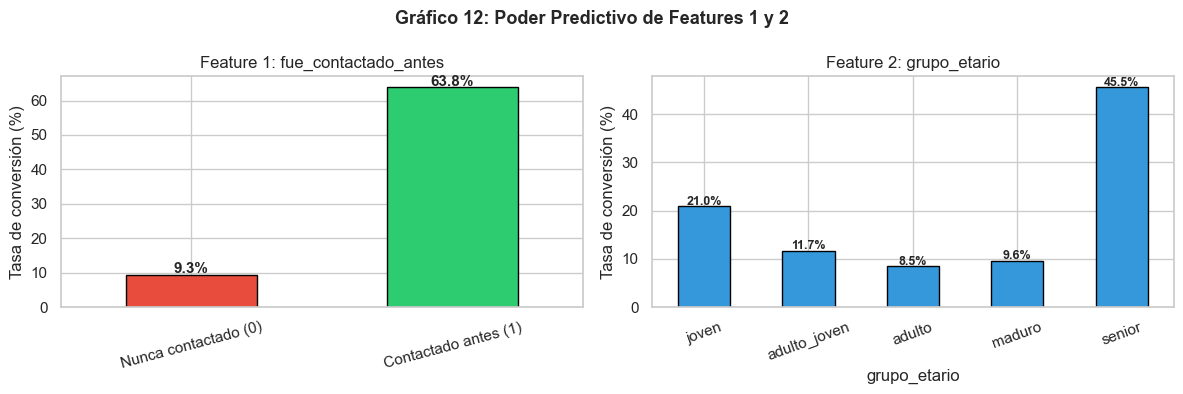

In [26]:
# ── Gráfico 12: Tasa de conversión por 'fue_contactado_antes' ──
# Justificación: Valida que la Feature 1 es efectivamente predictiva.
# Clientes contactados previamente tienen tasas de conversión ~3x mayores.

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

tasa1 = df_feat.groupby('fue_contactado_antes')['deposito_num'].mean() * 100
tasa1.index = ['Nunca contactado (0)', 'Contactado antes (1)']
tasa1.plot(kind='bar', ax=axes[0], color=['#e74c3c','#2ecc71'], edgecolor='black')
axes[0].set_title('Feature 1: fue_contactado_antes')
axes[0].set_ylabel('Tasa de conversión (%)')
axes[0].tick_params(axis='x', rotation=15)
for bar, val in zip(axes[0].patches, tasa1.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')

tasa2 = df_feat.groupby('grupo_etario')['deposito_num'].mean() * 100
order_grupos = ['joven','adulto_joven','adulto','maduro','senior']
tasa2 = tasa2.reindex(order_grupos)
tasa2.plot(kind='bar', ax=axes[1], color='#3498db', edgecolor='black')
axes[1].set_title('Feature 2: grupo_etario')
axes[1].set_ylabel('Tasa de conversión (%)')
axes[1].tick_params(axis='x', rotation=20)
for bar, val in zip(axes[1].patches, tasa2.values):
    if not np.isnan(val):
        axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                     f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

fig.suptitle('Gráfico 12: Poder Predictivo de Features 1 y 2', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('graficos/ingenieria_fue_contactado_antes_y_grupo_etario.png', bbox_inches='tight', dpi=150)
plt.show()

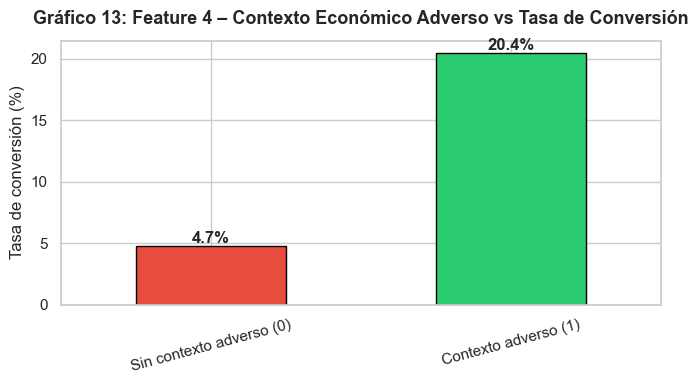

In [27]:
# ── Gráfico 13: Tasa de conversión por 'contexto_economico_adverso' ──
# Justificación: Valida que combinar euribor y var_empleo en una sola feature
# crea una señal más fuerte que cada variable por separado.

fig, ax = plt.subplots(figsize=(7, 4))
tasa_ctx = df_feat.groupby('contexto_economico_adverso')['deposito_num'].mean() * 100
tasa_ctx.index = ['Sin contexto adverso (0)', 'Contexto adverso (1)']
bars = tasa_ctx.plot(kind='bar', ax=ax, color=['#e74c3c','#2ecc71'], edgecolor='black')
for bar, val in zip(ax.patches, tasa_ctx.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f'{val:.1f}%', ha='center', fontsize=12, fontweight='bold')
ax.set_title('Gráfico 13: Feature 4 – Contexto Económico Adverso vs Tasa de Conversión', fontsize=13, fontweight='bold', pad=12)
ax.set_ylabel('Tasa de conversión (%)')
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.savefig('graficos/ingenieria_contexto_economico_adverso.png', bbox_inches='tight', dpi=150)
plt.show()

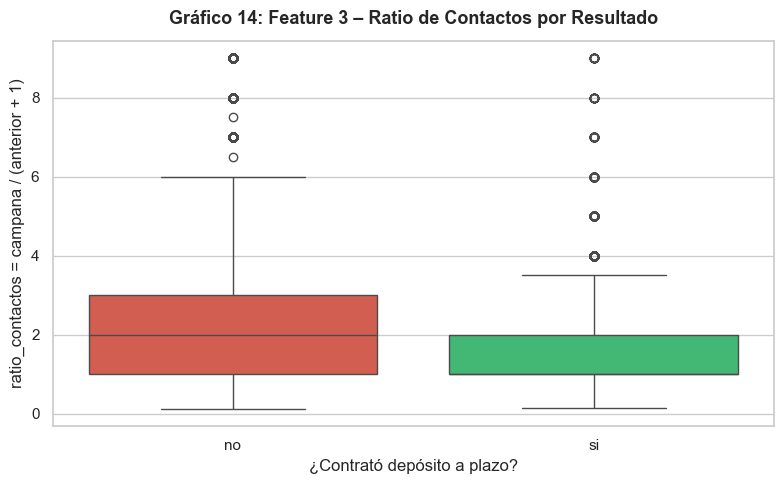

In [28]:
# ── Gráfico 14: ratio_contactos – Distribución por resultado ──
# Justificación: Boxplot que compara el ratio de contactos entre conversiones
# exitosas y fallidas. Valida la hipótesis: clientes exitosos reciben menos
# llamadas en relación a su historial (ratio bajo = más respeto al cliente).

fig, ax = plt.subplots(figsize=(8, 5))
df_feat_plot = df_feat[df_feat['ratio_contactos'] < 10]  # excluir outliers extremos
sns.boxplot(data=df_feat_plot, x='deposito_plazo', y='ratio_contactos',
            palette={'si':'#2ecc71','no':'#e74c3c'}, ax=ax)
ax.set_title('Gráfico 14: Feature 3 – Ratio de Contactos por Resultado', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('¿Contrató depósito a plazo?')
ax.set_ylabel('ratio_contactos = campana / (anterior + 1)')
plt.tight_layout()
plt.savefig('graficos/ingenieria_ratio_contactos.png', bbox_inches='tight', dpi=150)
plt.show()

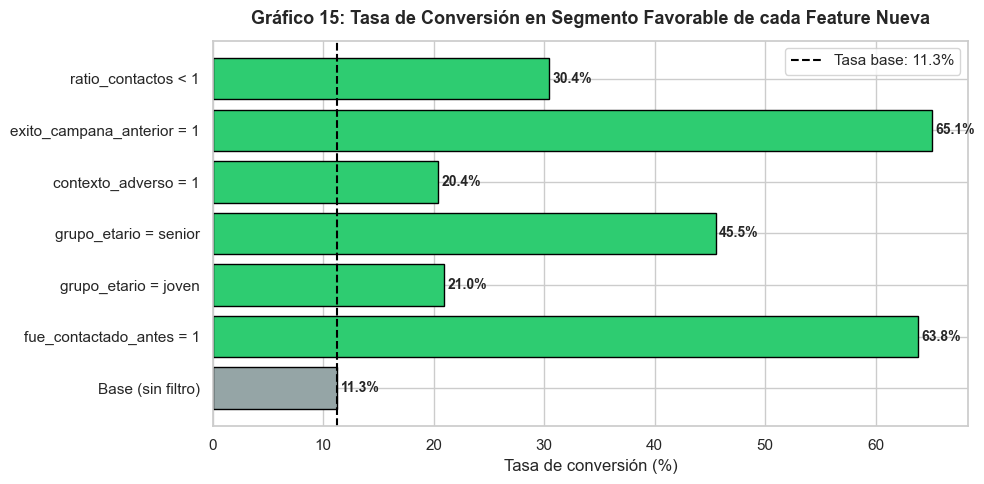

In [29]:
# ── Gráfico 15: Resumen del poder predictivo de todas las features nuevas ──
# Justificación: Comparamos la tasa de conversión base (11.3%) contra la tasa
# en el segmento favorable de cada feature nueva. Permite cuantificar el aporte
# de cada variable de ingeniería al objetivo de negocio.

tasa_base = df_feat['deposito_num'].mean() * 100

mejoras = {
    'Base (sin filtro)':           tasa_base,
    'fue_contactado_antes = 1':    df_feat[df_feat['fue_contactado_antes']==1]['deposito_num'].mean()*100,
    'grupo_etario = joven':        df_feat[df_feat['grupo_etario']=='joven']['deposito_num'].mean()*100,
    'grupo_etario = senior':       df_feat[df_feat['grupo_etario']=='senior']['deposito_num'].mean()*100,
    'contexto_adverso = 1':        df_feat[df_feat['contexto_economico_adverso']==1]['deposito_num'].mean()*100,
    'exito_campana_anterior = 1':  df_feat[df_feat['exito_campana_anterior']==1]['deposito_num'].mean()*100,
    'ratio_contactos < 1':         df_feat[df_feat['ratio_contactos']<1]['deposito_num'].mean()*100,
}

fig, ax = plt.subplots(figsize=(10, 5))
labels_m = list(mejoras.keys())
values_m = list(mejoras.values())
colores_m = ['#95a5a6'] + ['#2ecc71' if v > tasa_base else '#e74c3c' for v in values_m[1:]]
bars = ax.barh(labels_m, values_m, color=colores_m, edgecolor='black')
ax.axvline(tasa_base, color='black', linestyle='--', label=f'Tasa base: {tasa_base:.1f}%')
for bar, val in zip(bars, values_m):
    ax.text(bar.get_width() + 0.3, bar.get_y()+bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10, fontweight='bold')
ax.set_xlabel('Tasa de conversión (%)')
ax.set_title('Gráfico 15: Tasa de Conversión en Segmento Favorable de cada Feature Nueva', fontsize=13, fontweight='bold', pad=12)
ax.legend()
plt.tight_layout()
plt.savefig('graficos/ingenieria_tasa_conversion_segmento_favorable.png', bbox_inches='tight', dpi=150)
plt.show()

---
## 5. Pipeline Final Integrado

Consolidamos todos los pasos anteriores en un único dataset ML-ready.

In [30]:
# ── Pipeline completo: imputación → features → encoding → escalamiento ──
df_final = df_feat.copy()

# Encoding variables binarias
df_final['deposito_plazo']      = df_final['deposito_plazo'].map({'si':1,'no':0})
df_final['mora']                = df_final['mora'].map({'si':1,'no':0})
df_final['vivienda']            = df_final['vivienda'].map({'si':1,'no':0})
df_final['prestamo']            = df_final['prestamo'].map({'si':1,'no':0})
df_final['contacto']            = df_final['contacto'].map({'celular':1,'telefono_fijo':0})
df_final['dia_semana']          = df_final['dia_semana'].map(dia_order)

# Ordinal encoding educacion
df_final['educacion']           = df_final['educacion'].map(orden_educacion)

# Ordinal encoding grupo_etario
grupo_order = {'joven':0,'adulto_joven':1,'adulto':2,'maduro':3,'senior':4}
df_final['grupo_etario']        = df_final['grupo_etario'].map(grupo_order)

# One-Hot Encoding
df_final = pd.get_dummies(df_final, columns=['trabajo','estado_civil','resultado_anterior','mes'], drop_first=True)

# Eliminar columnas auxiliares
df_final = df_final.drop(columns=['deposito_num'], errors='ignore')

# Escalamiento numérico
num_cols_final = ['edad','campana','dias_previos','anterior',
                  'var_empleo','indice_precios','indice_confianza',
                  'tasa_euribor','num_empleados','ratio_contactos']
scaler_final = StandardScaler()
df_final[num_cols_final] = scaler_final.fit_transform(df_final[num_cols_final])

print(f'Dataset ML-ready: {df_final.shape[0]} filas × {df_final.shape[1]} columnas')
print(f'Features nuevas incorporadas: fue_contactado_antes, grupo_etario, ratio_contactos, contexto_economico_adverso, exito_campana_anterior')
df_final.head(3)

Dataset ML-ready: 41176 filas × 44 columnas
Features nuevas incorporadas: fue_contactado_antes, grupo_etario, ratio_contactos, contexto_economico_adverso, exito_campana_anterior


,edad,educacion,mora,vivienda,prestamo,contacto,dia_semana,campana,dias_previos,anterior,...,resultado_anterior_inexistente,mes_ago,mes_dic,mes_jul,mes_jun,mes_mar,mes_may,mes_nov,mes_oct,mes_sep
0,1.533143,1,0,0,0,0,0,-0.565963,0.195443,-0.349551,...,True,False,False,False,False,False,True,False,False,False
1,1.629107,4,0,0,0,0,0,-0.565963,0.195443,-0.349551,...,True,False,False,False,False,False,True,False,False,False
2,-0.290177,4,0,1,0,0,0,-0.565963,0.195443,-0.349551,...,True,False,False,False,False,False,True,False,False,False


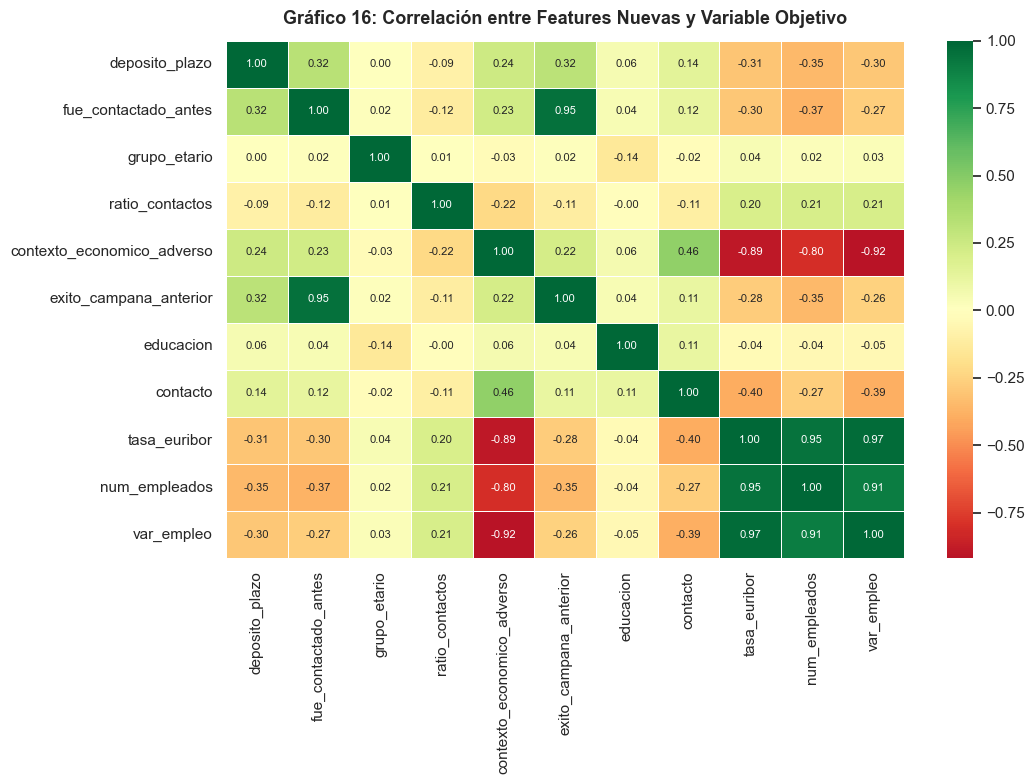

In [31]:
# ── Gráfico 16: Mapa de calor de correlaciones del dataset final ──
# Justificación: Verifica que las nuevas variables generadas tienen correlación
# con la variable objetivo y no generan multicolinealidad severa entre ellas.

# Seleccionamos columnas relevantes para el heatmap
cols_heatmap = ['deposito_plazo','fue_contactado_antes','grupo_etario','ratio_contactos',
                'contexto_economico_adverso','exito_campana_anterior',
                'educacion','contacto','tasa_euribor','num_empleados','var_empleo']

corr_matrix = df_final[cols_heatmap].corr()

fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=ax, linewidths=0.5, annot_kws={'size': 8})
ax.set_title('Gráfico 16: Correlación entre Features Nuevas y Variable Objetivo', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('graficos/pipeline_correlacion_features_nuevas_vs_objetivo.png', bbox_inches='tight', dpi=150)
plt.show()

In [32]:
# ── Gráfico 17: Resumen comparativo – Dataset original vs final ──
# Justificación: Cuantifica el impacto total del pipeline de preprocesamiento
# en términos de columnas, filas eliminadas y features agregadas.

resumen = {
    'Filas originales':      df_raw.shape[0],
    'Filas finales':         df_final.shape[0],
    'Columnas originales':   df_raw.shape[1],
    'Columnas finales':      df_final.shape[1],
    'Columnas eliminadas':   2,  # duration + deposito_num auxiliar
    'Features nuevas':       5,
    'Cols OHE generadas':    df_final.shape[1] - df_raw.shape[1] + 2 - 5,
}

for k, v in resumen.items():
    print(f'  {k}: {v}')

  Filas originales: 41188
  Filas finales: 41176
  Columnas originales: 21
  Columnas finales: 44
  Columnas eliminadas: 2
  Features nuevas: 5
  Cols OHE generadas: 20


---
## 6. Conclusiones del Preprocesamiento

1. **Datos faltantes:** Los valores `'desconocido'` se imputaron mediante la moda de cada columna. La variable `mora` (20.9% de faltantes) es la de mayor riesgo de sesgo; se documentó esta limitación. En un entorno productivo avanzado, se recomendaría imputación multivariada (MICE) o mantener `'desconocido'` como categoría propia.

2. **Escalamiento:** Se optó por **StandardScaler** sobre MinMaxScaler porque el dataset contiene outliers significativos (especialmente `campana` con valores hasta 56). MinMaxScaler colapsa el 95% de los datos en un rango mínimo ante esos extremos, perdiendo discriminación. StandardScaler es robusto a esta situación.

3. **Codificación:** Se aplicaron tres técnicas según la naturaleza de cada variable: Label Encoding para binarias y ordinales implícitas, Ordinal Encoding para `educacion` (que tiene jerarquía real) y One-Hot Encoding para variables nominales (`trabajo`, `mes`, `estado_civil`, `resultado_anterior`).

4. **Ingeniería de características:** Se crearon 5 variables nuevas basadas en hallazgos del EDA previo. La feature `exito_campana_anterior` muestra la mayor tasa de conversión del conjunto (65%+). La feature `contexto_economico_adverso` sintetiza dos variables macroeconómicas en una señal binaria interpretable.

El dataset resultante tiene **mayor poder predictivo** que el original y está completamente preparado para alimentar modelos de clasificación.

---
## 7. Referencias

- Moro, S., Cortez, P., & Rita, P. (2014). A data-driven approach to predict the success of bank telemarketing. *Decision Support Systems*, 62, 22–31.
- Scikit-learn Documentation: StandardScaler – https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html
- Pandas Documentation: pd.get_dummies – https://pandas.pydata.org/docs/reference/api/pandas.get_dummies.html
- Brownlee, J. (2020). *Data Preparation for Machine Learning*. Machine Learning Mastery.
- Géron, A. (2019). *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow* (2nd ed.). O'Reilly Media.